In [12]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [13]:
df1 = pd.read_csv("C:/Users/Windows/Desktop/GSM8655184_A549_Ctrl-1.counts.txt",
                  sep ='\t',header=0,skiprows = 1)
df1.columns =['Geneid','ctrl1']
df1.set_index ('Geneid',inplace =True)
print(df1.head())

                 ctrl1
Geneid                
ENSG00000223972      0
ENSG00000227232     98
ENSG00000278267      6
ENSG00000243485      0
ENSG00000284332      0


In [14]:
df2 = pd.read_csv("C:/Users/Windows/Desktop/GSM8655185_A549_Ctrl-2.counts.txt",
                  sep ='\t',header =0,skiprows =1)
df2.columns =['Geneid','ctrl2']
df2.set_index('Geneid',inplace=True)
print(df2.head())

                 ctrl2
Geneid                
ENSG00000223972      0
ENSG00000227232     61
ENSG00000278267      8
ENSG00000243485      0
ENSG00000284332      0


In [15]:
df3 = pd.read_csv("C:/Users/Windows/Desktop/GSM8655186_A549_Ctrl-3.counts.txt",sep ='\t',header =0,skiprows =1)
df3.columns =['Geneid','ctrl3']
df3.set_index ('Geneid',inplace =True)
print(df3.head())

                 ctrl3
Geneid                
ENSG00000223972      0
ENSG00000227232     43
ENSG00000278267      1
ENSG00000243485      0
ENSG00000284332      0


In [16]:
df4 = pd.read_csv("C:/Users/Windows/Desktop/GSM8655187_A549_ZNF296OE-1.counts.txt",sep ='\t',header =0,skiprows =1)
df4.columns =['Geneid','OE1']
df4.set_index ('Geneid',inplace =True)
print(df4.head())

                 OE1
Geneid              
ENSG00000223972    0
ENSG00000227232   62
ENSG00000278267    2
ENSG00000243485    1
ENSG00000284332    0


In [17]:
df5 = pd.read_csv("C:/Users/Windows/Desktop/GSM8655188_A549_ZNF296OE-2.counts.txt",sep ='\t',header =0,skiprows =1)
df5.columns =['Geneid','OE2']
df5.set_index ('Geneid',inplace =True)
print(df5.head())

                 OE2
Geneid              
ENSG00000223972    0
ENSG00000227232   71
ENSG00000278267    4
ENSG00000243485    0
ENSG00000284332    0


In [18]:
df6 = pd.read_csv("C:/Users/Windows/Desktop/GSM8655189_A549_ZNF296OE-3.counts.txt",sep ='\t',header =0,skiprows =1)
df6.columns =['Geneid','OE3']
df6.set_index ('Geneid',inplace =True)
print(df6.head())

                 OE3
Geneid              
ENSG00000223972    0
ENSG00000227232   69
ENSG00000278267    3
ENSG00000243485    0
ENSG00000284332    0


In [19]:
df_concat =pd.concat([df1,df2,df3,df4,df5,df6],axis=1)

In [20]:
df_concat

,ctrl1,ctrl2,ctrl3,OE1,OE2,OE3
Geneid,,,,,,
ENSG00000223972,0,0,0,0,0,0
ENSG00000227232,98,61,43,62,71,69
ENSG00000278267,6,8,1,2,4,3
ENSG00000243485,0,0,0,1,0,0
ENSG00000284332,0,0,0,0,0,0
...,...,...,...,...,...,...
ENSG00000271254,432,353,372,108,199,264
ENSG00000275405,4,0,1,0,0,0
ENSG00000275987,1,0,1,5,0,10


In [21]:
print("过滤前的基因数量:", len(df_concat))


过滤前的基因数量: 58735


In [22]:
# 方法1: 保留在至少X个样本中表达量 > Y 的基因
min_samples = 6  # 至少在6个样本中表达
min_expression = 5  # 表达量阈值
# 计算每个基因在多少样本中表达量 > 阈值
expressed_in_samples = (df_concat > min_expression).sum(axis=1)
filtered_genes = df_concat[expressed_in_samples >= min_samples] #df_concat[...] 的作用是用布尔索引筛选 df_concat 里的行（基因），只保留满足条件的那些行。

In [ ]:
expressed_in_samples
filtered_genes

ctrl1    int64
ctrl2    int64
ctrl3    int64
OE1      int64
OE2      int64
OE3      int64
dtype: object

In [ ]:
# 计算每个基因在多少样本中表达量 > 阈值
expressed_in_samples = (df_concat > min_expression).sum(axis=1)
filtered_genes = df_concat[expressed_in_samples >= min_samples]

print("过滤后的基因数量:", len(filtered_genes))
print("过滤掉的比例: {:.1%}".format(1 - len(filtered_genes)/len(df_concat)))

# 查看过滤后的数据
print("\n过滤后的数据前5行:")
print(filtered_genes.head())

过滤后的基因数量: 15205
过滤掉的比例: 74.1%

过滤后的数据前5行:
                 ctrl1  ctrl2  ctrl3   OE1   OE2   OE3
Geneid                                                
ENSG00000227232     98     61     43    62    71    69
ENSG00000279457    122    131    175   204   238   166
ENSG00000228463     15     29     22    16    21    18
ENSG00000225630   2945   2818   2900  1759  2404  2336
ENSG00000237973   1319   1320   1263  1280  1238  1147


In [ ]:

# ✅ log2 转换（避免 log(0)）
log_counts = np.log2(filtered_genes + 1)

# ✅ 可选：查看转换后的前几行
print("log2 转换后的表达矩阵（前5行）:")
print(log_counts.head())

log2 转换后的表达矩阵（前5行）:
                     ctrl1      ctrl2      ctrl3        OE1        OE2  \
Geneid                                                                   
ENSG00000227232   6.629357   5.954196   5.459432   5.977280   6.169925   
ENSG00000279457   6.942515   7.044394   7.459432   7.679480   7.900867   
ENSG00000228463   4.000000   4.906891   4.523562   4.087463   4.459432   
ENSG00000225630  11.524542  11.460968  11.502335  10.781360  11.231821   
ENSG00000237973  10.366322  10.367415  10.303781  10.323055  10.274960   

                       OE3  
Geneid                      
ENSG00000227232   6.129283  
ENSG00000279457   7.383704  
ENSG00000228463   4.247928  
ENSG00000225630  11.190442  
ENSG00000237973  10.164907  


In [ ]:
log_counts.index

Index(['ENSG00000227232', 'ENSG00000279457', 'ENSG00000228463',
       'ENSG00000225630', 'ENSG00000237973', 'ENSG00000248527',
       'ENSG00000198744', 'ENSG00000228327', 'ENSG00000237491',
       'ENSG00000228794',
       ...
       'ENSG00000210194', 'ENSG00000198727', 'ENSG00000210195',
       'ENSG00000210196', 'ENSG00000276256', 'ENSG00000273748',
       'ENSG00000278817', 'ENSG00000277196', 'ENSG00000276345',
       'ENSG00000271254'],
      dtype='object', name='Geneid', length=15205)

In [ ]:
log_counts.isna().sum()

ctrl1    0
ctrl2    0
ctrl3    0
OE1      0
OE2      0
OE3      0
dtype: int64

In [ ]:
from scipy.stats import ttest_ind

# 先计算 p-value
p_values = []
for idx, row in log_counts.iterrows():
    ctrl = row[['ctrl1', 'ctrl2', 'ctrl3']].values
    OE = row[['OE1', 'OE2', 'OE3']].values
    stat, p = ttest_ind(ctrl, OE, equal_var=False)
    p_values.append(p)

# 再计算 log2FC
log2FC = []
for idx, row in log_counts.iterrows():
    ctrl = row[['ctrl1', 'ctrl2', 'ctrl3']].values
    OE = row[['OE1', 'OE2', 'OE3']].values
    log2FC.append(np.mean(OE) - np.mean(ctrl))

# 构建结果表
results = pd.DataFrame({
    'Geneid': log_counts.index,
    'log2FC': log2FC,
    'p_value': p_values
})

c:\Users\Windows\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Windows\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Windows\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Windows\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision 

In [ ]:
results

,Geneid,log2FC,p_value
0,ENSG00000227232,0.077834,0.841003
1,ENSG00000279457,0.505904,0.081070
2,ENSG00000228463,-0.211877,0.516247
3,ENSG00000225630,-0.428074,0.094319
4,ENSG00000237973,-0.091532,0.179831
...,...,...,...
15200,ENSG00000273748,-0.633912,0.011205
15201,ENSG00000278817,1.171900,0.012327
15202,ENSG00000277196,0.465721,0.152316
15203,ENSG00000276345,1.588823,0.038444


In [ ]:
'''你可以先筛掉表达值在所有样本都完全一样的基因，
再做后续的 t 检验和 log2FC 计算。方法如下：'''

# 去掉所有样本表达值都一样的基因
filtered = log_counts[log_counts.nunique(axis=1) > 1]

# 计算 p-value
from scipy.stats import ttest_ind
p_values = []
for idx, row in filtered.iterrows():
    ctrl = row[['ctrl1', 'ctrl2', 'ctrl3']].values
    OE = row[['OE1', 'OE2', 'OE3']].values
    stat, p = ttest_ind(ctrl, OE, equal_var=False)
    p_values.append(p)

# 计算 log2FC
log2FC = []
for idx, row in filtered.iterrows():
    ctrl = row[['ctrl1', 'ctrl2', 'ctrl3']].values
    OE = row[['OE1', 'OE2', 'OE3']].values
    log2FC.append(np.mean(OE) - np.mean(ctrl))

# 构建结果表
results = pd.DataFrame({
    'Geneid': filtered.index,
    'log2FC': log2FC,
    'p_value': p_values
})

c:\Users\Windows\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Windows\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Windows\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Windows\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision 

In [ ]:
'''
解决方法：可以进一步过滤掉方差极小的基因
'''
# 去掉方差很小的基因（比如方差小于 1e-6）
filtered = log_counts[log_counts.std(axis=1) > 1e-6]

# 后续检验同之前
from scipy.stats import ttest_ind
p_values = []
log2FC = []
for idx, row in filtered.iterrows():
    ctrl = row[['ctrl1', 'ctrl2', 'ctrl3']].values
    OE = row[['OE1', 'OE2', 'OE3']].values
    stat, p = ttest_ind(ctrl, OE, equal_var=False)
    p_values.append(p)
    log2FC.append(np.mean(OE) - np.mean(ctrl))

results = pd.DataFrame({
    'Geneid': filtered.index,
    'log2FC': log2FC,
    'p_value': p_values
})

c:\Users\Windows\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Windows\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Windows\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Windows\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision 

In [ ]:

'''
解决方法：可以进一步过滤掉方差极小的基因
'''
# 去掉方差很小的基因（比如方差小于 1e-4）
filtered = log_counts[log_counts.std(axis=1) > 1e-4]

# 后续检验同之前
from scipy.stats import ttest_ind
p_values = []
log2FC = []
for idx, row in filtered.iterrows():
    ctrl = row[['ctrl1', 'ctrl2', 'ctrl3']].values
    OE = row[['OE1', 'OE2', 'OE3']].values
    stat, p = ttest_ind(ctrl, OE, equal_var=False)
    p_values.append(p)
    log2FC.append(np.mean(OE) - np.mean(ctrl))

results = pd.DataFrame({
    'Geneid': filtered.index,
    'log2FC': log2FC,
    'p_value': p_values
})

c:\Users\Windows\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Windows\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Windows\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Windows\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision 

In [ ]:
results

,Geneid,log2FC,p_value
0,ENSG00000227232,0.077834,0.841003
1,ENSG00000279457,0.505904,0.081070
2,ENSG00000228463,-0.211877,0.516247
3,ENSG00000225630,-0.428074,0.094319
4,ENSG00000237973,-0.091532,0.179831
...,...,...,...
15200,ENSG00000273748,-0.633912,0.011205
15201,ENSG00000278817,1.171900,0.012327
15202,ENSG00000277196,0.465721,0.152316
15203,ENSG00000276345,1.588823,0.038444


In [ ]:
# filepath: untitled:Untitled-1.ipynb?jupyter-notebook
sig_genes = results[(results['p_value'] < 0.05) & (results['log2FC'].abs() > 1)]
print("显著差异基因数量:", len(sig_genes))
print(sig_genes.head())

显著差异基因数量: 3005
             Geneid    log2FC   p_value
14  ENSG00000187634  1.292992  0.000249
21  ENSG00000187608 -3.031329  0.001153
41  ENSG00000272455  1.052977  0.007448
44  ENSG00000160072 -2.629197  0.004385
50  ENSG00000197530  1.033214  0.019144


In [ ]:
'''
import mygene

# 筛选显著差异基因
sig_genes = results[(results['p_value'] < 0.05) & (results['log2FC'].abs() > 1)]
print("显著差异基因数量:", len(sig_genes))
print(sig_genes.head())


# Ensembl ID 转官方基因名（Symbol）
mg = mygene.MyGeneInfo()
ensg_list = sig_genes['Geneid'].tolist()
query_result = mg.querymany(ensg_list, scopes='ensembl.gene', fields='symbol', species='human')

# 转成DataFrame
map_df = pd.DataFrame(query_result)[['query', 'symbol']]
map_df = map_df.rename(columns={'query': 'Geneid', 'symbol': 'Symbol'})

# 合并并替换Geneid为Symbol
sig_genes = sig_genes.merge(map_df, on='Geneid', how='left')
sig_genes['Geneid'] = sig_genes['Symbol']
sig_genes = sig_genes.drop(['Symbol'], axis=1)

print(sig_genes.head())
'''

'\nimport mygene\n\n# 筛选显著差异基因\nsig_genes = results[(results[\'p_value\'] < 0.05) & (results[\'log2FC\'].abs() > 1)]\nprint("显著差异基因数量:", len(sig_genes))\nprint(sig_genes.head())\n\n\n# Ensembl ID 转官方基因名（Symbol）\nmg = mygene.MyGeneInfo()\nensg_list = sig_genes[\'Geneid\'].tolist()\nquery_result = mg.querymany(ensg_list, scopes=\'ensembl.gene\', fields=\'symbol\', species=\'human\')\n\n# 转成DataFrame\nmap_df = pd.DataFrame(query_result)[[\'query\', \'symbol\']]\nmap_df = map_df.rename(columns={\'query\': \'Geneid\', \'symbol\': \'Symbol\'})\n\n# 合并并替换Geneid为Symbol\nsig_genes = sig_genes.merge(map_df, on=\'Geneid\', how=\'left\')\nsig_genes[\'Geneid\'] = sig_genes[\'Symbol\']\nsig_genes = sig_genes.drop([\'Symbol\'], axis=1)\n\nprint(sig_genes.head())\n'

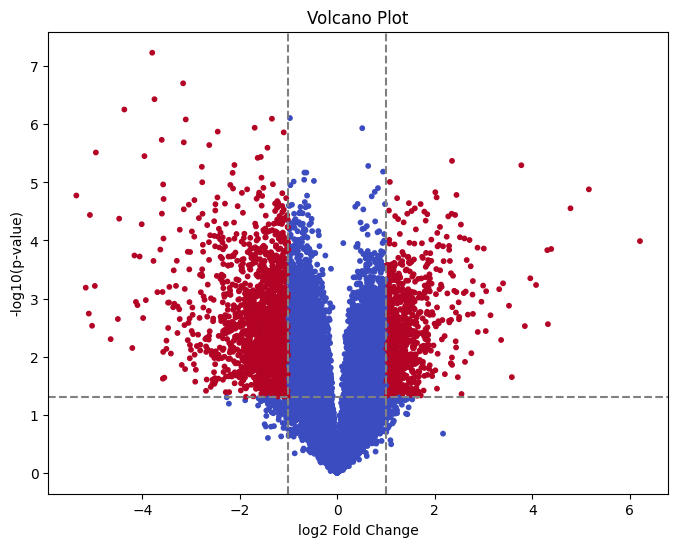

In [ ]:
import matplotlib.pyplot as plt

# 计算 -log10(p-value)
results['-log10(p_value)'] = -np.log10(results['p_value'])

# 设置阈值
fc_thresh = 1
p_thresh = 0.05

# 画火山图
plt.figure(figsize=(8,6))
plt.scatter(results['log2FC'], results['-log10(p_value)'], 
            c=( (results['p_value'] < p_thresh) & (results['log2FC'].abs() > fc_thresh) ),
            cmap='coolwarm', s=10)

plt.axhline(-np.log10(p_thresh), color='grey', linestyle='--')
plt.axvline(fc_thresh, color='grey', linestyle='--')
plt.axvline(-fc_thresh, color='grey', linestyle='--')
plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(p-value)')
plt.title('Volcano Plot')
plt.show()

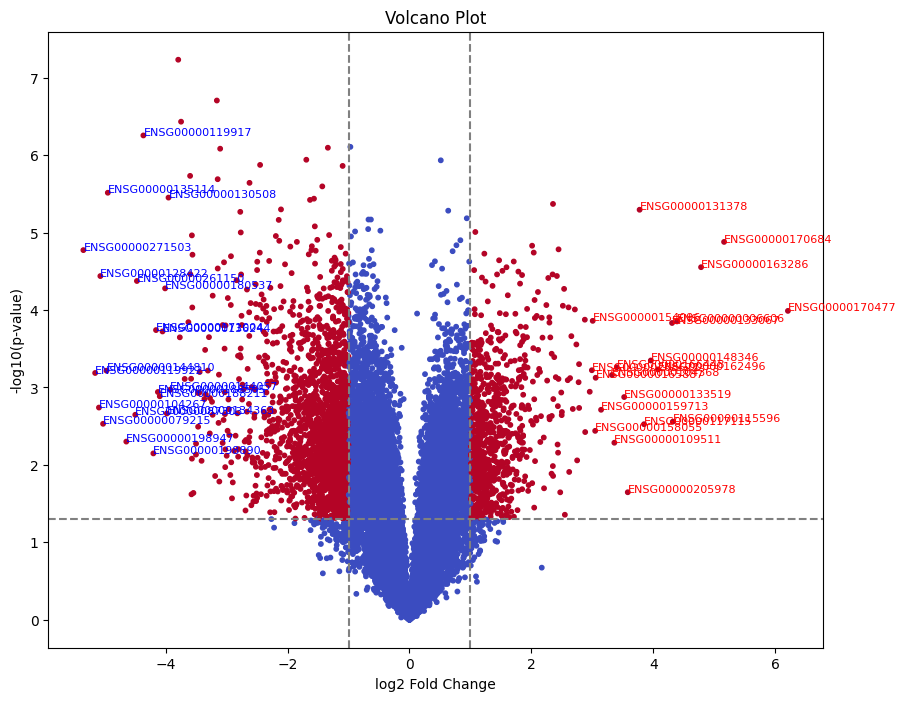

In [ ]:
import matplotlib.pyplot as plt

# 计算 -log10(p-value)
results['-log10(p_value)'] = -np.log10(results['p_value'])

# 设置阈值
fc_thresh = 1
p_thresh = 0.05

# 画火山图
plt.figure(figsize=(10,8))
plt.scatter(results['log2FC'], results['-log10(p_value)'], 
            c=( (results['p_value'] < p_thresh) & (results['log2FC'].abs() > fc_thresh) ),
            cmap='coolwarm', s=10)

plt.axhline(-np.log10(p_thresh), color='grey', linestyle='--')
plt.axvline(fc_thresh, color='grey', linestyle='--')
plt.axvline(-fc_thresh, color='grey', linestyle='--')
plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(p-value)')
plt.title('Volcano Plot')

# 标注上调前20个基因（红色）
up_genes = results[(results['log2FC'] > fc_thresh) & (results['p_value'] < p_thresh)]
top_up = up_genes.sort_values('log2FC', ascending=False).head(20)
for i, row in top_up.iterrows():
    plt.text(row['log2FC'], row['-log10(p_value)'], row['Geneid'], color='red', fontsize=8)

# 标注下调前20个基因（蓝色）
down_genes = results[(results['log2FC'] < -fc_thresh) & (results['p_value'] < p_thresh)]
top_down = down_genes.sort_values('log2FC').head(20)
for i, row in top_down.iterrows():
    plt.text(row['log2FC'], row['-log10(p_value)'], row['Geneid'], color='blue', fontsize=8)

plt.show()

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
1 input query terms found dup hits:	[('ENSG00000175711', 2)]
126 input query terms found no hit:	['ENSG00000230699', 'ENSG00000271895', 'ENSG00000284602', 'ENSG00000116883', 'ENSG00000273373', 'ENS


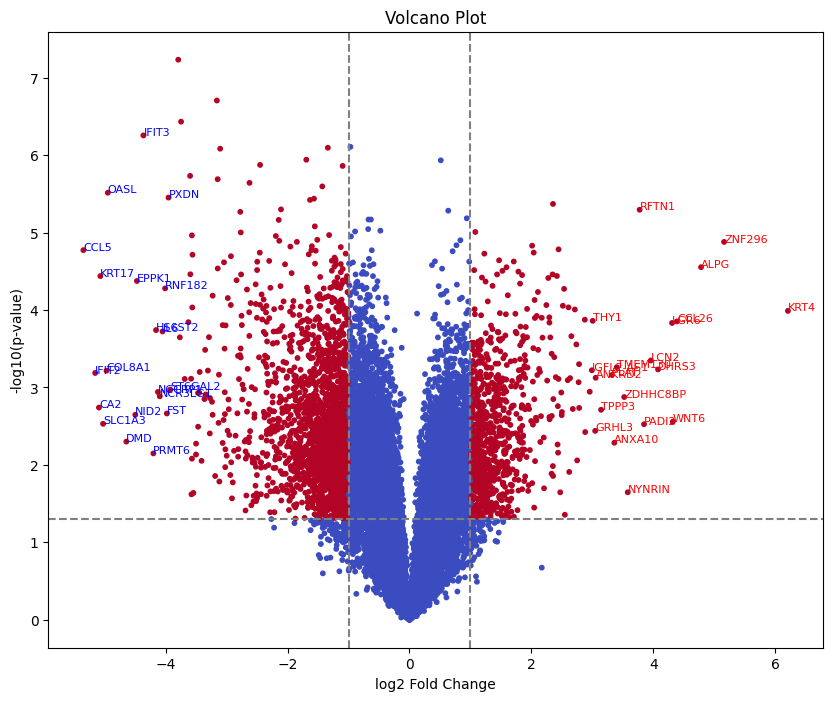

In [ ]:
import mygene
import matplotlib.pyplot as plt

# 批量查询官方基因名
mg = mygene.MyGeneInfo()
ensg_list = results['Geneid'].tolist()
query_result = mg.querymany(ensg_list, scopes='ensembl.gene', fields='symbol', species='human')

# 构建映射表
map_df = pd.DataFrame(query_result)[['query', 'symbol']]
map_df = map_df.rename(columns={'query': 'Geneid', 'symbol': 'Symbol'})

# 合并并替换Geneid为Symbol
results = results.merge(map_df, on='Geneid', how='left')
results['Geneid'] = results['Symbol']
results = results.drop(['Symbol'], axis=1)

# 计算 -log10(p-value)
results['-log10(p_value)'] = -np.log10(results['p_value'])

# 设置阈值
fc_thresh = 1
p_thresh = 0.05

# 画火山图
plt.figure(figsize=(10,8))
plt.scatter(results['log2FC'], results['-log10(p_value)'], 
            c=( (results['p_value'] < p_thresh) & (results['log2FC'].abs() > fc_thresh) ),
            cmap='coolwarm', s=10)

plt.axhline(-np.log10(p_thresh), color='grey', linestyle='--')
plt.axvline(fc_thresh, color='grey', linestyle='--')
plt.axvline(-fc_thresh, color='grey', linestyle='--')
plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(p-value)')
plt.title('Volcano Plot')

# 标注上调前20个基因（红色）
up_genes = results[(results['log2FC'] > fc_thresh) & (results['p_value'] < p_thresh)]
top_up = up_genes.sort_values('log2FC', ascending=False).head(20)
for i, row in top_up.iterrows():
    plt.text(row['log2FC'], row['-log10(p_value)'], row['Geneid'], color='red', fontsize=8)

# 标注下调前20个基因（蓝色）
down_genes = results[(results['log2FC'] < -fc_thresh) & (results['p_value'] < p_thresh)]
top_down = down_genes.sort_values('log2FC').head(20)
for i, row in top_down.iterrows():
    plt.text(row['log2FC'], row['-log10(p_value)'], row['Geneid'], color='blue', fontsize=8)

plt.show()

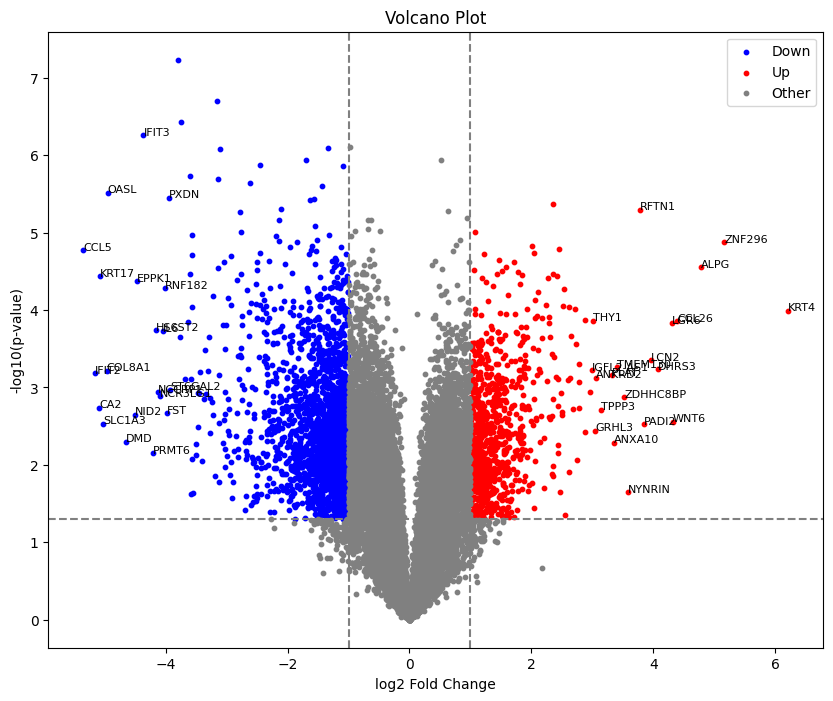

In [ ]:
import mygene
import matplotlib.pyplot as plt
'''
# 批量将Ensembl ID转为官方基因名（Symbol）
mg = mygene.MyGeneInfo()
ensg_list = results['Geneid'].tolist()
query_result = mg.querymany(ensg_list, scopes='ensembl.gene', fields='symbol', species='human')
map_df = pd.DataFrame(query_result)[['query', 'symbol']]
map_df = map_df.rename(columns={'query': 'Geneid', 'symbol': 'Symbol'})
results = results.merge(map_df, on='Geneid', how='left')
results['Geneid'] = results['Symbol']
results = results.drop(['Symbol'], axis=1)
'''

# 计算 -log10(p-value)
results['-log10(p_value)'] = -np.log10(results['p_value'])

# 设置阈值
fc_thresh = 1
p_thresh = 0.05

plt.figure(figsize=(10,8))

# 下调点（蓝色）
down = (results['log2FC'] < -fc_thresh) & (results['p_value'] < p_thresh)
plt.scatter(results.loc[down, 'log2FC'], results.loc[down, '-log10(p_value)'], color='blue', s=10, label='Down')

# 上调点（红色）
up = (results['log2FC'] > fc_thresh) & (results['p_value'] < p_thresh)
plt.scatter(results.loc[up, 'log2FC'], results.loc[up, '-log10(p_value)'], color='red', s=10, label='Up')

# 其他点（灰色）
other = ~(up | down)
plt.scatter(results.loc[other, 'log2FC'], results.loc[other, '-log10(p_value)'], color='grey', s=10, label='Other')

plt.axhline(-np.log10(p_thresh), color='grey', linestyle='--')
plt.axvline(fc_thresh, color='grey', linestyle='--')
plt.axvline(-fc_thresh, color='grey', linestyle='--')
plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(p-value)')
plt.title('Volcano Plot')

# 标注上调前20个基因（默认颜色）
top_up = results.loc[up].sort_values('log2FC', ascending=False).head(20)
for i, row in top_up.iterrows():
    plt.text(row['log2FC'], row['-log10(p_value)'], row['Geneid'], fontsize=8)

# 标注下调前20个基因（默认颜色）
top_down = results.loc[down].sort_values('log2FC').head(20)
for i, row in top_down.iterrows():
    plt.text(row['log2FC'], row['-log10(p_value)'], row['Geneid'], fontsize=8)

plt.legend()
plt.show()

In [ ]:
'''
你的 query_result 里有些基因查不到 symbol，导致 ['symbol'] not in index 报错。
你可以先过滤掉没有 symbol 的行：
'''
import mygene
import matplotlib.pyplot as plt

mg = mygene.MyGeneInfo()
ensg_list = results['Geneid'].tolist()
query_result = mg.querymany(ensg_list, scopes='ensembl.gene', fields='symbol', species='human')

# 只保留有 symbol 的结果
map_df = pd.DataFrame(query_result)
map_df = map_df[map_df['symbol'].notna()][['query', 'symbol']]
map_df = map_df.rename(columns={'query': 'Geneid', 'symbol': 'Symbol'})

results = results.merge(map_df, on='Geneid', how='left')
results['Geneid'] = results['Symbol'].fillna(results['Geneid'])
results = results.drop(['Symbol'], axis=1)

# 计算 -log10(p-value)
results['-log10(p_value)'] = -np.log10(results['p_value'])

fc_thresh = 1
p_thresh = 0.05

plt.figure(figsize=(10,8))
down = (results['log2FC'] < -fc_thresh) & (results['p_value'] < p_thresh)
plt.scatter(results.loc[down, 'log2FC'], results.loc[down, '-log10(p_value)'], color='blue', s=10, label='Down')
up = (results['log2FC'] > fc_thresh) & (results['p_value'] < p_thresh)
plt.scatter(results.loc[up, 'log2FC'], results.loc[up, '-log10(p_value)'], color='red', s=10, label='Up')
other = ~(up | down)
plt.scatter(results.loc[other, 'log2FC'], results.loc[other, '-log10(p_value)'], color='grey', s=10, label='Other')

plt.axhline(-np.log10(p_thresh), color='grey', linestyle='--')
plt.axvline(fc_thresh, color='grey', linestyle='--')
plt.axvline(-fc_thresh, color='grey', linestyle='--')
plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(p-value)')
plt.title('Volcano Plot')

top_up = results.loc[up].sort_values('log2FC', ascending=False).head(20)
for i, row in top_up.iterrows():
    plt.text(row['log2FC'], row['-log10(p_value)'], row['Geneid'], fontsize=8)
top_down = results.loc[down].sort_values('log2FC').head(20)
for i, row in top_down.iterrows():
    plt.text(row['log2FC'], row['-log10(p_value)'], row['Geneid'], fontsize=8)

plt.legend()
plt.show()

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
15206 input query terms found no hit:	['WASH7P', 'WASH9P', 'RPL23AP21', 'MTND2P28', 'MTCO1P12', 'MTATP6P1', 'MTCO3P12', 'nan', 'LINC01409'


KeyError: 'symbol'

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
15206 input query terms found no hit:	['WASH7P', 'WASH9P', 'RPL23AP21', 'MTND2P28', 'MTCO1P12', 'MTATP6P1', 'MTCO3P12', 'nan', 'LINC01409'


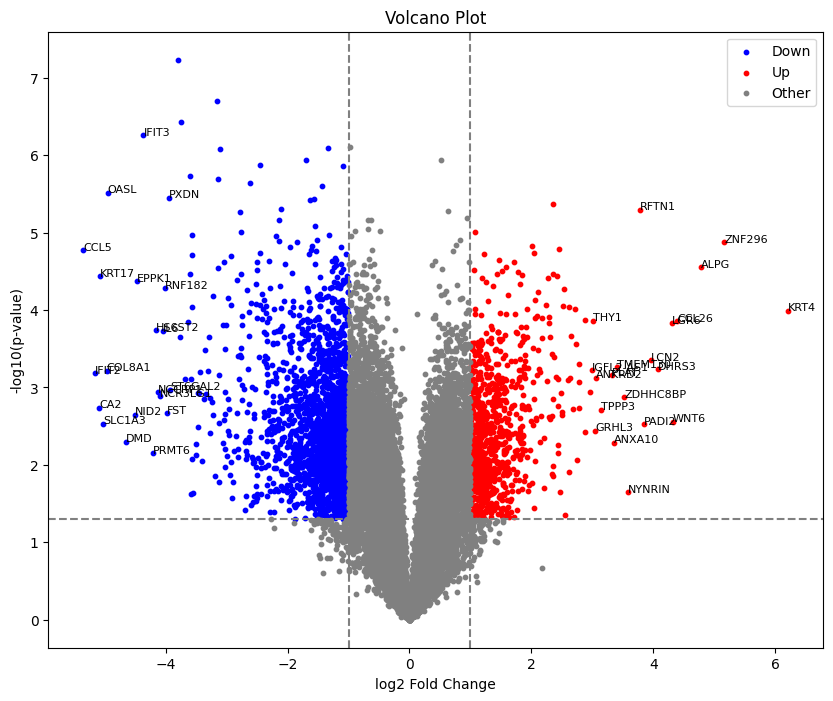

In [ ]:
'''
你的代码报 KeyError: 'symbol'，说明 query_result 里有些行没有 symbol 字段。
请用下面的方式过滤掉没有 symbol 的行
'''

import mygene
import matplotlib.pyplot as plt

mg = mygene.MyGeneInfo()
ensg_list = results['Geneid'].tolist()
query_result = mg.querymany(ensg_list, scopes='ensembl.gene', fields='symbol', species='human')

# 只保留有 symbol 的结果，避免 KeyError
map_df = pd.DataFrame(query_result)
if 'symbol' in map_df.columns:
    map_df = map_df[map_df['symbol'].notna()][['query', 'symbol']]
    map_df = map_df.rename(columns={'query': 'Geneid', 'symbol': 'Symbol'})
    results = results.merge(map_df, on='Geneid', how='left')
    results['Geneid'] = results['Symbol'].fillna(results['Geneid'])
    results = results.drop(['Symbol'], axis=1)

# 计算 -log10(p-value)
results['-log10(p_value)'] = -np.log10(results['p_value'])

fc_thresh = 1
p_thresh = 0.05

plt.figure(figsize=(10,8))
down = (results['log2FC'] < -fc_thresh) & (results['p_value'] < p_thresh)
plt.scatter(results.loc[down, 'log2FC'], results.loc[down, '-log10(p_value)'], color='blue', s=10, label='Down')
up = (results['log2FC'] > fc_thresh) & (results['p_value'] < p_thresh)
plt.scatter(results.loc[up, 'log2FC'], results.loc[up, '-log10(p_value)'], color='red', s=10, label='Up')
other = ~(up | down)
plt.scatter(results.loc[other, 'log2FC'], results.loc[other, '-log10(p_value)'], color='grey', s=10, label='Other')

plt.axhline(-np.log10(p_thresh), color='grey', linestyle='--')
plt.axvline(fc_thresh, color='grey', linestyle='--')
plt.axvline(-fc_thresh, color='grey', linestyle='--')
plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(p-value)')
plt.title('Volcano Plot')

top_up = results.loc[up].sort_values('log2FC', ascending=False).head(20)
for i, row in top_up.iterrows():
    plt.text(row['log2FC'], row['-log10(p_value)'], row['Geneid'], fontsize=8)
top_down = results.loc[down].sort_values('log2FC').head(20)
for i, row in top_down.iterrows():
    plt.text(row['log2FC'], row['-log10(p_value)'], row['Geneid'], fontsize=8)

plt.legend()
plt.show()

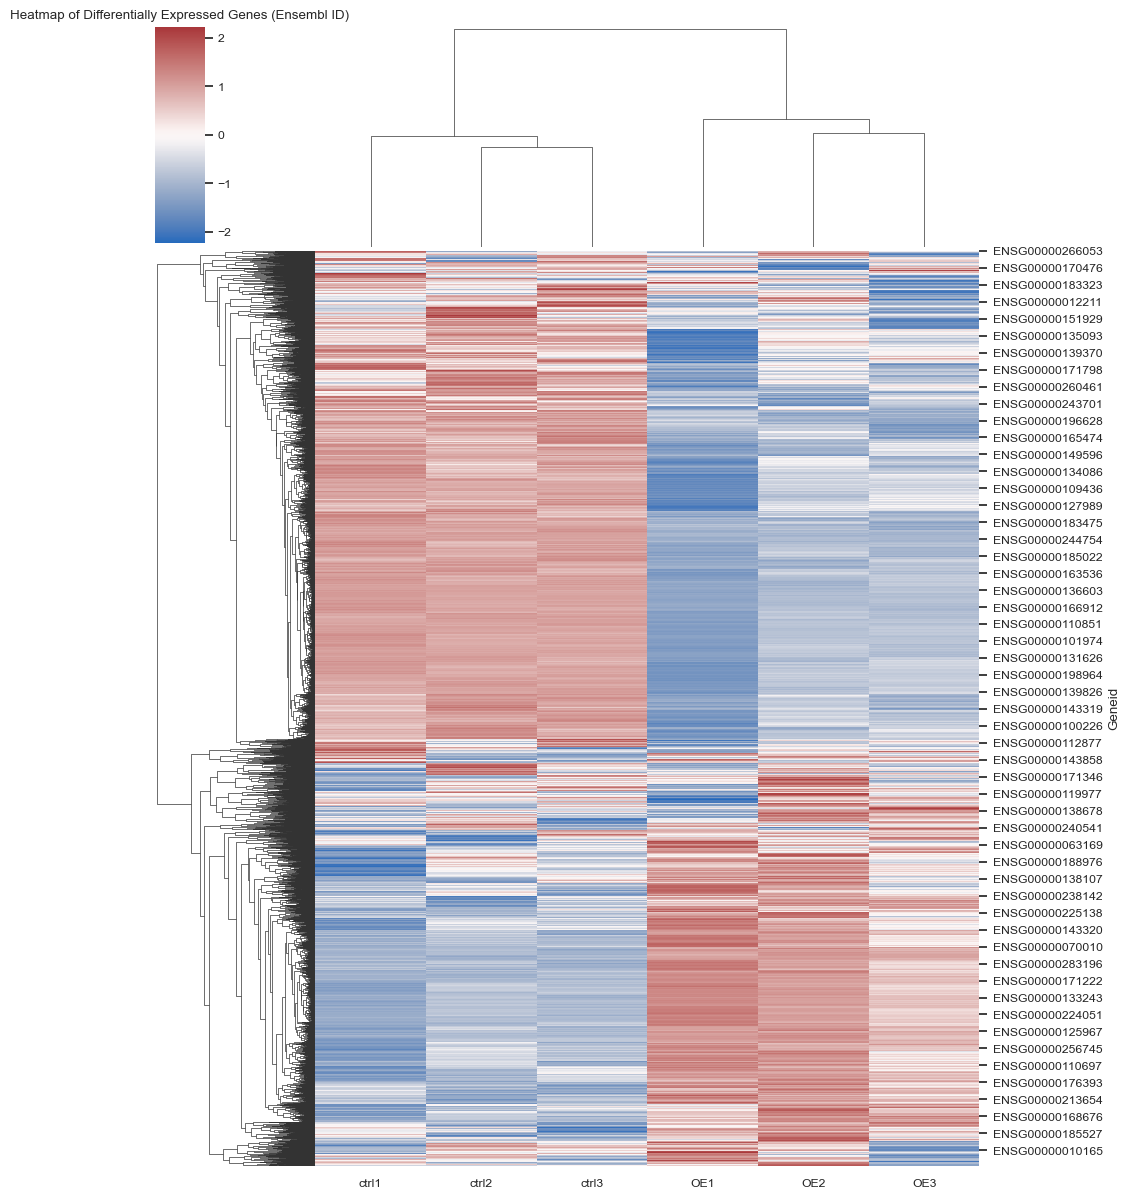

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler



# Step 1: 从表达矩阵中提取这些基因的表达值
heatmap_data = log_counts

# Step 2: Z-score 标准化（按行）
scaled_data = pd.DataFrame(
    StandardScaler().fit_transform(heatmap_data.T).T,
    index=heatmap_data.index,
    columns=heatmap_data.columns
)

# Step 3: 绘制热图
sns.set(font_scale=0.8)
sns.clustermap(scaled_data, cmap='vlag', figsize=(10, 12))
plt.title("Heatmap of Differentially Expressed Genes (Ensembl ID)")
plt.show()



In [ ]:
from gseapy import enrichr

enr = enrichr(gene_list=gene_symbols,
              gene_sets=['GO_Biological_Process_2021', 'KEGG_2021_Human'],
              organism='Human',
              outdir='enrichr_results')


NameError: name 'gene_symbols' is not defined

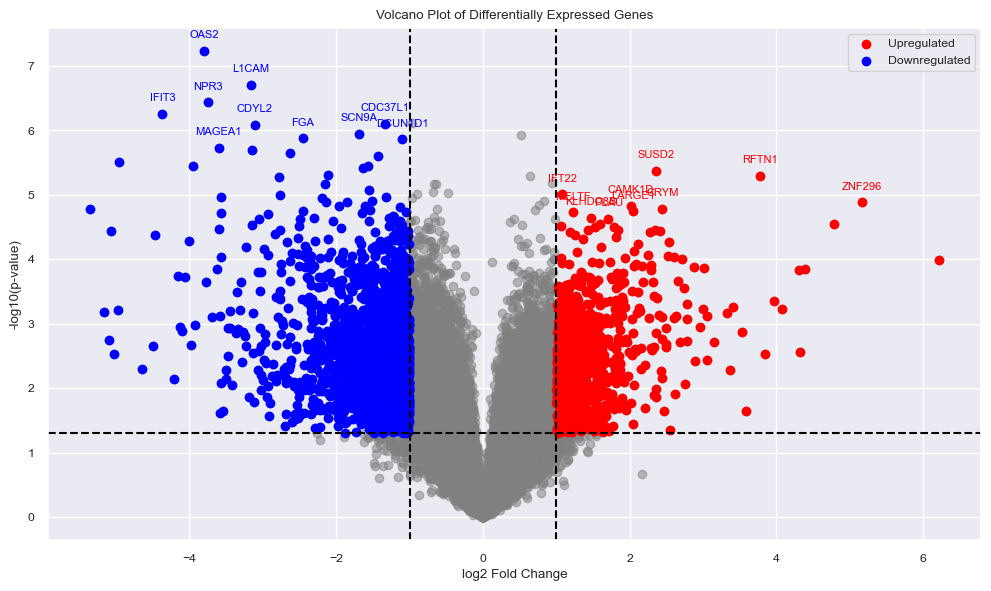

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

results['-log10(p_value)'] = -np.log10(results['p_value'])

# 选出前10个显著上调基因
top_up = up.sort_values(by='p_value').head(10)

# 选出前10个显著下调基因
top_down = down.sort_values(by='p_value').head(10)


plt.figure(figsize=(10, 6))

# 所有点
plt.scatter(results['log2FC'], results['-log10(p_value)'], color='grey', alpha=0.5)

# 显著上调基因（log2FC > 1 且 p < 0.05）
up = results[(results['log2FC'] > 1) & (results['p_value'] < 0.05)]
plt.scatter(up['log2FC'], up['-log10(p_value)'], color='red', label='Upregulated')

# 显著下调基因（log2FC < -1 且 p < 0.05）
down = results[(results['log2FC'] < -1) & (results['p_value'] < 0.05)]
plt.scatter(down['log2FC'], down['-log10(p_value)'], color='blue', label='Downregulated')


# 标注上调基因
for i, row in top_up.iterrows():
    plt.text(row['log2FC'], row['-log10(p_value)'] + 0.2, row['Geneid'],
             fontsize=8, color='red', ha='center')

# 标注下调基因
for i, row in top_down.iterrows():
    plt.text(row['log2FC'], row['-log10(p_value)'] + 0.2, row['Geneid'],
             fontsize=8, color='blue', ha='center')


# 阈值线
plt.axhline(-np.log10(0.05), color='black', linestyle='--')
plt.axvline(1, color='black', linestyle='--')
plt.axvline(-1, color='black', linestyle='--')

# 标签和标题
plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(p-value)')
plt.title('Volcano Plot of Differentially Expressed Genes')
plt.legend()
plt.tight_layout()
plt.show()


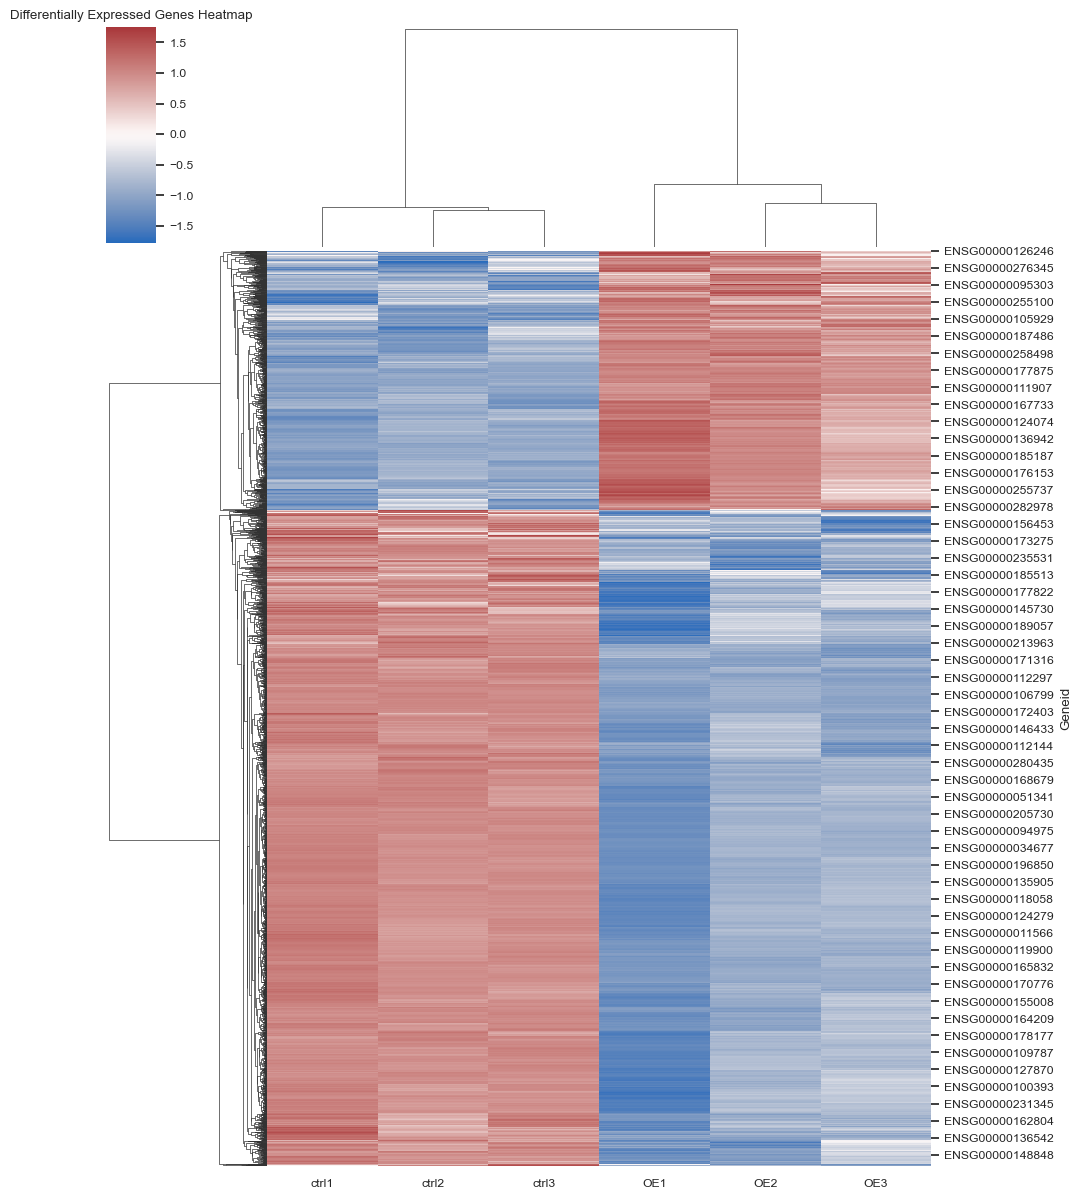

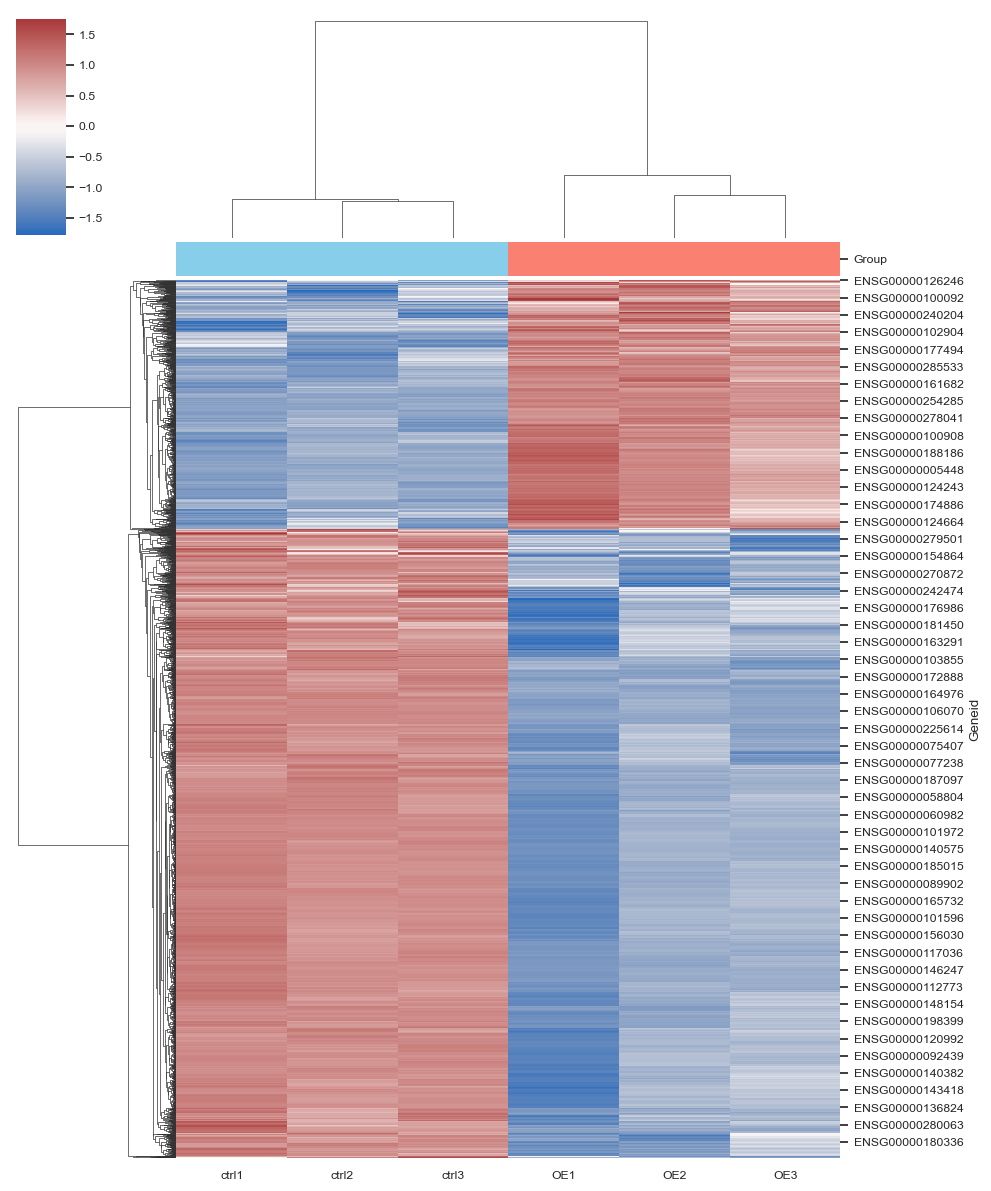

In [ ]:
valid_genes = sig_genes['Geneid'].dropna()
heatmap_data = log_counts.loc[valid_genes]

# Step 2: Z-score 标准化（按行）
from sklearn.preprocessing import StandardScaler
scaled_data = pd.DataFrame(
    StandardScaler().fit_transform(heatmap_data.T).T,
    index=heatmap_data.index,
    columns=heatmap_data.columns
)

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=0.8)
sns.clustermap(scaled_data, cmap='vlag', figsize=(10, 12), 
               row_cluster=True, col_cluster=True)
plt.title("Differentially Expressed Genes Heatmap")
plt.show()

group_info = pd.DataFrame({
    'Sample': scaled_data.columns,
    'Group': ['ctrl'] * 3 + ['OE'] * 3  # 根据你的样本数量调整
}).set_index('Sample')

col_colors = group_info['Group'].map({'ctrl': 'skyblue', 'OE': 'salmon'})

sns.clustermap(scaled_data, cmap='vlag', figsize=(10, 12), 
               col_colors=col_colors, row_cluster=True, col_cluster=True)



In [ ]:
import mygene

mg = mygene.MyGeneInfo()
ensg_list = sig_genes['Geneid'].dropna().tolist()
query_result = mg.querymany(ensg_list, scopes='ensembl.gene', fields='symbol', species='human')

# 转成 Symbol 列表
symbol_list = [item['symbol'] for item in query_result if 'symbol' in item]
gene_symbols = list(set(symbol_list))  # 去重

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
13 input query terms found no hit:	['ENSG00000261159', 'ENSG00000112096', 'ENSG00000270157', 'ENSG00000239407', 'ENSG00000148362', 'ENS


In [ ]:
from gseapy import enrichr

enr = enrichr(
    gene_list=symbol_list,
    gene_sets=['GO_Biological_Process_2021', 'KEGG_2021_Human'],
    organism='Human',
    outdir='enrichr_results',
    cutoff=0.05
)


In [ ]:
len(enr.results) # 查看富集结果数量
print(dtype(enr))

<class 'gseapy.enrichr.Enrichr'>


<Axes: title={'center': 'KEGG Enrichment'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

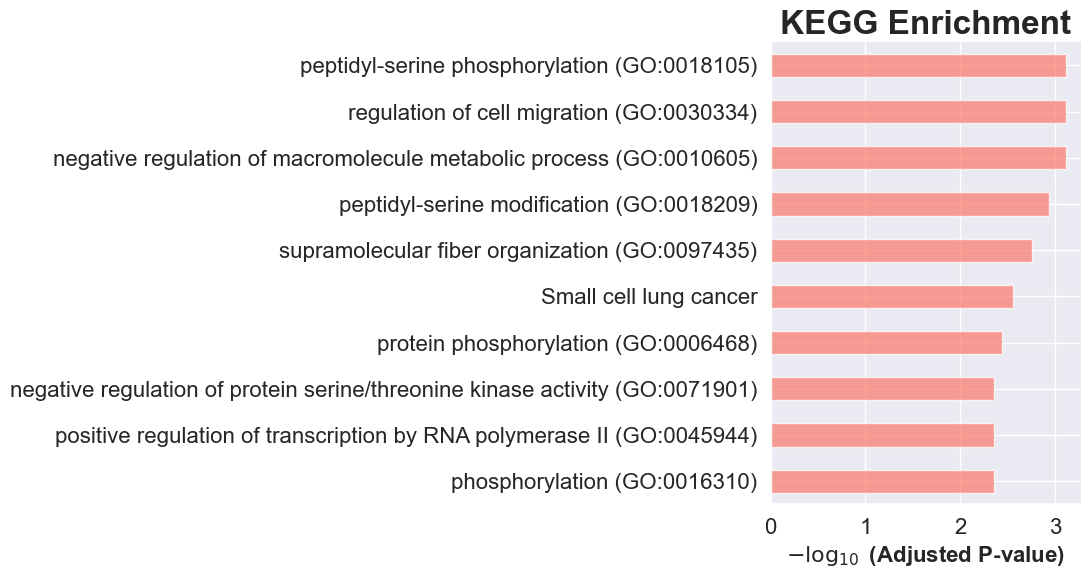

In [ ]:
import gseapy as gp

gp.barplot(df=enr.results, title='KEGG Enrichment', cutoff=0.1, top_term=10)


<Axes: title={'center': 'KEGG Enrichment (Downregulated Genes)'}, xlabel='Combined Score'>

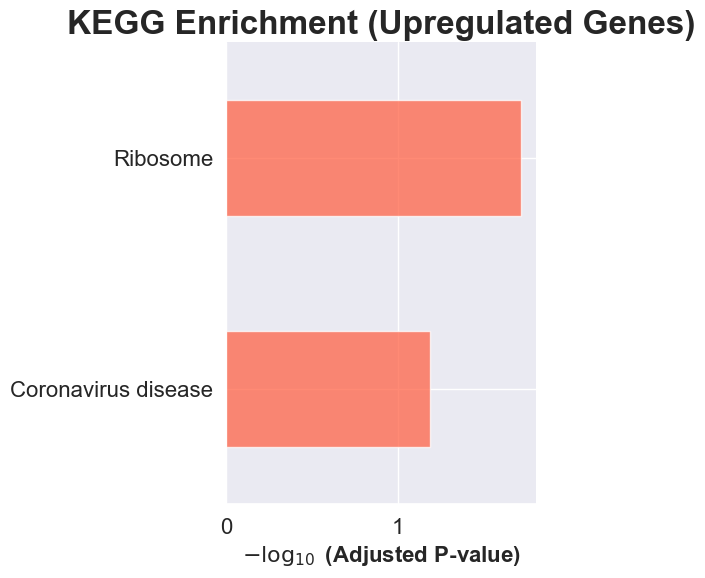

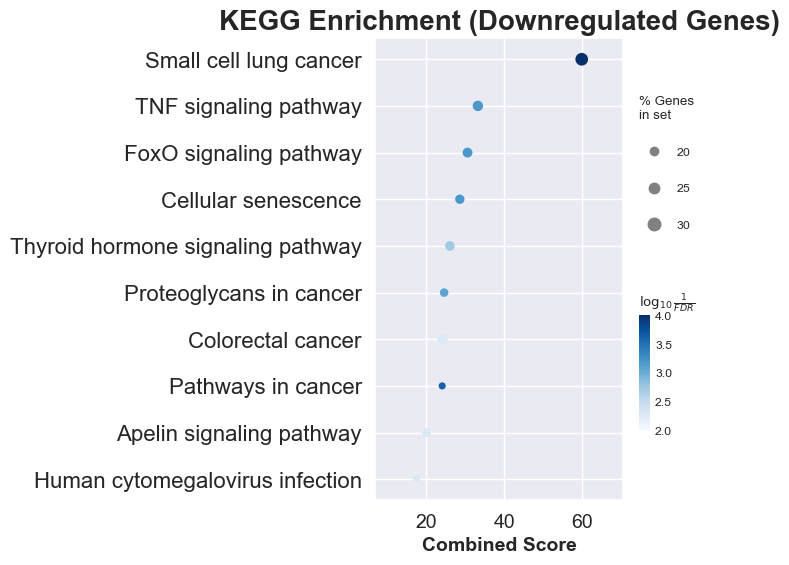

In [ ]:
# 上调基因
up_gene_list = results[(results['log2FC'] > 1) & (results['p_value'] < 0.05)]['Geneid'].dropna().tolist()

# 下调基因
down_gene_list = results[(results['log2FC'] < -1) & (results['p_value'] < 0.05)]['Geneid'].dropna().tolist()

from gseapy import enrichr

kegg_up = enrichr(gene_list=up_gene_list, gene_sets='KEGG_2021_Human', organism='Human', outdir=None, cutoff=0.1)
kegg_down = enrichr(gene_list=down_gene_list, gene_sets='KEGG_2021_Human', organism='Human', outdir=None, cutoff=0.1)

# 查看上调基因富集的 KEGG 通路
kegg_up.results.head(10)

# 查看下调基因富集的 KEGG 通路
kegg_down.results.head(10)

import gseapy as gp

gp.barplot(df=kegg_up.results, title='KEGG Enrichment (Upregulated Genes)', cutoff=0.1, top_term=10, color='tomato')
gp.dotplot(df=kegg_down.results, title='KEGG Enrichment (Downregulated Genes)', cutoff=0.1, top_term=10, cmap='Blues')


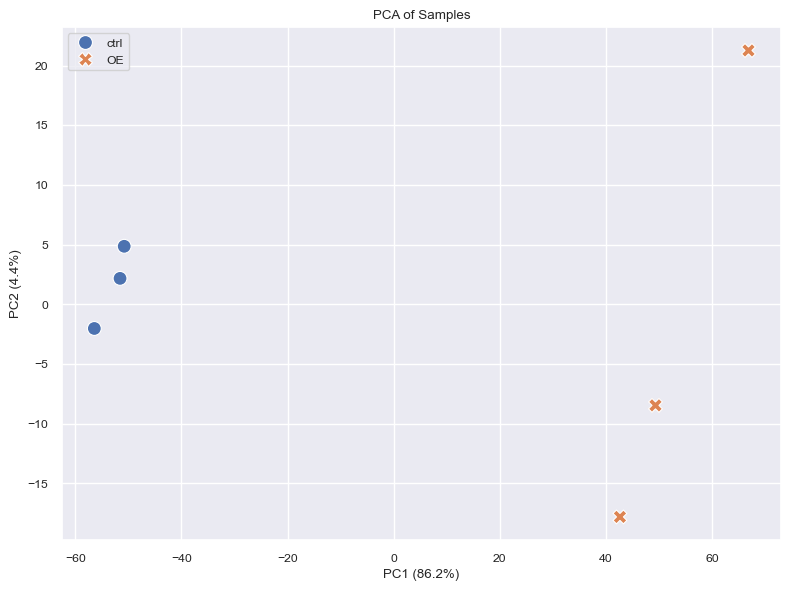

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Step 1: 使用过滤后的 log2 表达矩阵（基因 × 样本）
# 如果你已经过滤了低表达和低方差基因：
X = filtered.T  # 转置：样本为行，基因为列

# ✅ Step 2: 运行 PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

# ✅ Step 3: 构建结果 DataFrame
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Sample': X.index
})

# ✅ Step 4: 添加分组信息（可选）
# 示例：根据样本名判断分组
pca_df['Group'] = pca_df['Sample'].apply(lambda x: 'ctrl' if 'ctrl' in x else 'OE')

# ✅ Step 5: 绘图
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Group', style='Group', s=100)
plt.title('PCA of Samples')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.tight_layout()
plt.show()


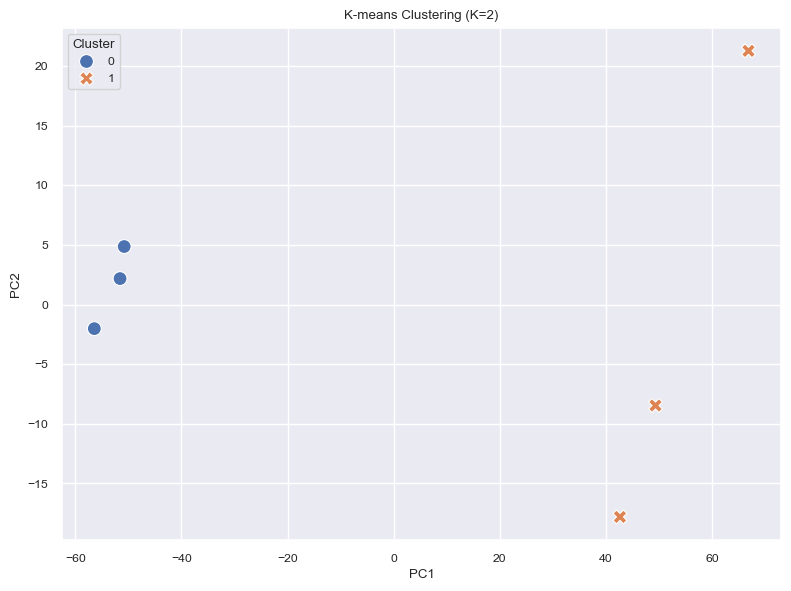

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Step 1: 准备表达矩阵（样本为行，基因为列）
X = filtered.T  # 转置：样本为行，基因为特征

# ✅ Step 2: 设置聚类数 K（例如分成 2 类）
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X)

# ✅ Step 3: 构建结果 DataFrame
cluster_df = pd.DataFrame({
    'Sample': X.index,
    'Cluster': labels,
    'PC1': PCA(n_components=2).fit_transform(X)[:, 0],
    'PC2': PCA(n_components=2).fit_transform(X)[:, 1]
})

# ✅ Step 4: 可视化聚类结果
plt.figure(figsize=(8, 6))
sns.scatterplot(data=cluster_df, x='PC1', y='PC2', hue='Cluster', style='Cluster', s=100)
plt.title(f'K-means Clustering (K={k})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()
